In [6]:
import os
Root = r'C:\Users\user\Desktop\THESIS\data2'
os.chdir(Root)

In [7]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D,
                                     Activation, Dropout, BatchNormalization,
                                     Flatten, Dense, AveragePooling2D)
from tensorflow.keras.optimizers import Adam
import cv2


In [9]:
data = r'C:\Users\user\Desktop\THESIS\data2'
No_breast_cancer = r'C:\Users\user\Desktop\THESIS\data2\0'
Yes_breast_cancer = r'C:\Users\user\Desktop\THESIS\data2\1'

In [10]:
dirlist=[No_breast_cancer, Yes_breast_cancer]
classes=['No', 'Yes']
filepaths=[]
labels=[]
for i,j in zip(dirlist, classes):
    filelist=os.listdir(i)
    for f in filelist:
        filepath=os.path.join (i,f)
        filepaths.append(filepath)
        labels.append(j)
print ('filepaths: ', len(filepaths), '   labels: ', len(labels))

filepaths:  4577    labels:  4577


creation dataframe

In [11]:
import pandas as pd
Files=pd.Series(filepaths, name='filepaths')
Label=pd.Series(labels, name='labels')
df=pd.concat([Files,Label], axis=1)
df=pd.DataFrame(np.array(df).reshape(4577,2), columns = ['filepaths', 'labels'])
df.head()

,filepaths,labels
0,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No
1,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No
2,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No
3,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No
4,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No


In [12]:
import pandas as pd
import numpy as np

#path to save
save_path = r"C:\Users\user\Desktop\THESIS\data2\data.csv"

# Create the DataFrame
Files = pd.Series(filepaths, name='filepaths')
Label = pd.Series(labels, name='labels')

df = pd.concat([Files, Label], axis=1)

df = pd.DataFrame(np.array(df).reshape(4577, 2), columns=['filepaths', 'labels'])
df.to_csv(save_path, index=False)

print(f"CSV saved successfully at:\n{save_path}")


CSV saved successfully at:
C:\Users\user\Desktop\THESIS\data2\data.csv


# Data cleaning 

In [44]:
print("\n Missing values:")
print(df.isnull().sum())


 Missing values:
filepaths    0
labels       0
dtype: int64


In [45]:
duplicates = df.duplicated().sum()
print(f"\n Duplicate rows: {duplicates}")


 Duplicate rows: 0


In [46]:
print("\n Label distribution:")
print(df['labels'].value_counts())


 Label distribution:
labels
Yes    2417
No     2160
Name: count, dtype: int64


In [47]:
print("\n first 5 rows of the dataset:")
print(df.head())


 first 5 rows of the dataset:
                                           filepaths labels
0  C:\Users\user\Desktop\THESIS\data2\0\12911_129...     No
1  C:\Users\user\Desktop\THESIS\data2\0\12911_129...     No
2  C:\Users\user\Desktop\THESIS\data2\0\12911_129...     No
3  C:\Users\user\Desktop\THESIS\data2\0\12911_129...     No
4  C:\Users\user\Desktop\THESIS\data2\0\12911_129...     No


# EDA

C:\Users\user\AppData\Local\Temp\ipykernel_12564\2292172432.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='labels', palette={'Yes': 'crimson', 'No': 'skyblue'})


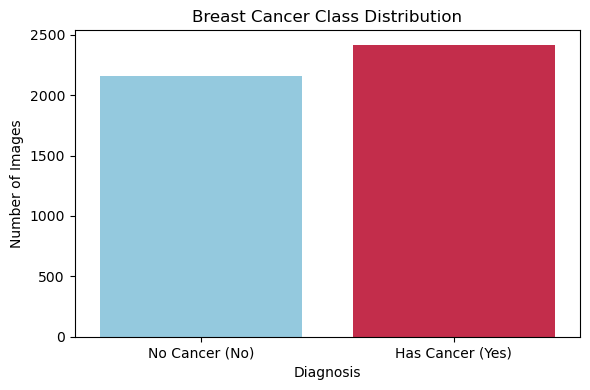

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ensure consistent casing
df['labels'] = df['labels'].str.strip().str.capitalize() 

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='labels', palette={'Yes': 'crimson', 'No': 'skyblue'})
plt.title("Breast Cancer Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.xticks([1, 0], ["Has Cancer (Yes)", "No Cancer (No)"])
plt.tight_layout()
plt.show()

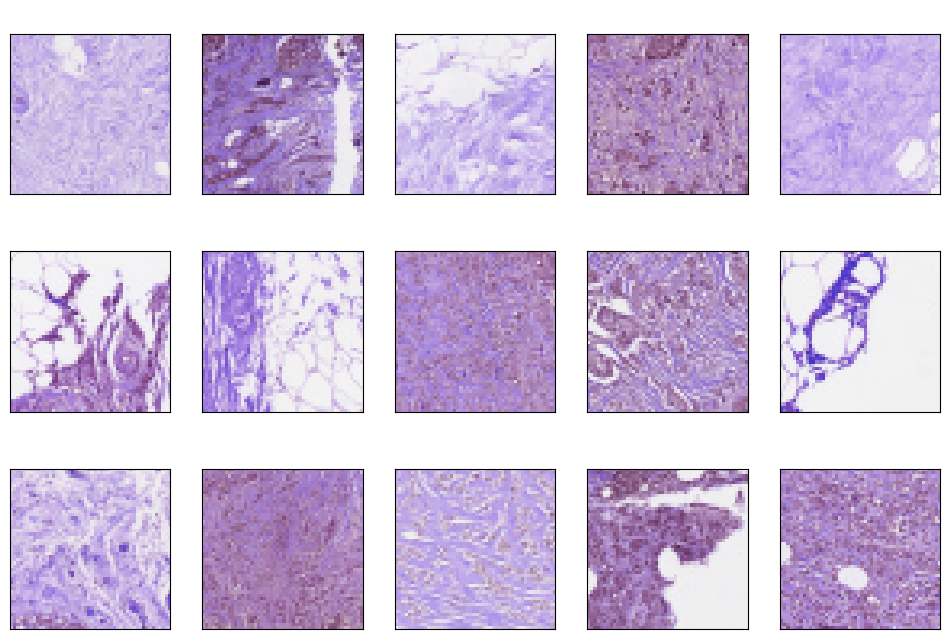

In [13]:
plt.figure(figsize=(12,8))
for i in range(15):
    random = np.random.randint(1,len(df))
    plt.subplot(3,5,i+1)
    plt.imshow(cv2.imread(df.loc[random,"filepaths"]))
    plt.title(df.loc[random, "labels"], size = 15, color = "white") 
    plt.xticks([])
    plt.yticks([])
    
plt.show()

# Split

In [13]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, train_size=0.95, random_state=0)
train_new, valid = train_test_split(train, train_size=0.90, random_state=0)

print(f"train set shape: {train_new.shape}")
print(f"test set shape: {test.shape}")
print(f"validation set shape: {valid.shape}")

train set shape: (3913, 2)
test set shape: (229, 2)
validation set shape: (435, 2)


In [14]:
train_datagen = ImageDataGenerator(rescale = 1./255.,rotation_range = 40,
                                   width_shift_range = 0.2, 
                                   height_shift_range = 0.2, 
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True,
                                   vertical_flip =True)
test_datagen = ImageDataGenerator(rescale = 1.0/255.)

In [15]:
train_gen = train_datagen.flow_from_dataframe(dataframe = train_new,
                                              x_col = 'filepaths', y_col ='labels',
                                              target_size = (224,224), batch_size = 32, 
                                              class_mode = 'binary', shuffle = True)
val_gen = train_datagen.flow_from_dataframe(valid, 
                                            target_size=(224,224), x_col = 'filepaths', y_col ='labels', 
                                            class_mode='binary',
                                            batch_size= 16, shuffle=True)
test_gen = test_datagen.flow_from_dataframe(test,
                                            target_size = (224,224), x_col = 'filepaths', y_col ='labels',
                                             class_mode = 'binary',
                                            batch_size = 16, shuffle = False)

Found 3913 validated image filenames belonging to 2 classes.
Found 435 validated image filenames belonging to 2 classes.
Found 229 validated image filenames belonging to 2 classes.


In [16]:
# one batch from the generator shape
images, labels = next(train_gen)  

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


# Bidirectional LSTM (BLSTM)

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Entrée image (224x224x3) -> aplatie -> reshaped pour séquence
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),  # Normalisation intégrée

    layers.Flatten(),  # Aplatir les images
    layers.Reshape((224, 224*3)),  # Séquence (timesteps, features)

    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64)),

    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint("BLSTM_classifier.keras", save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.5175 - loss: 0.6925
Epoch 1: val_loss improved from inf to 0.68494, saving model to BLSTM_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 85s 632ms/step - accuracy: 0.5177 - loss: 0.6925 - val_accuracy: 0.5632 - val_loss: 0.6849
Epoch 2/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.6709 - loss: 0.6376
Epoch 2: val_loss improved from 0.68494 to 0.49143, saving model to BLSTM_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 87s 712ms/step - accuracy: 0.6712 - loss: 0.6372 - val_accuracy: 0.7862 - val_loss: 0.4914
Epoch 3/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7766 - loss: 0.4908
Epoch 3: val_loss improved from 0.49143 to 0.46182, saving model to BLSTM_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.7767 - loss: 0.4908 - val_accuracy: 0.8138 - val_loss: 0.4618
Epoch 4/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7736 - loss: 0.4991
Epoch 4: val_loss improved 

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.8290 - loss: 0.3649

Test Accuracy : 82.10% | Test Loss : 0.3803
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step

Rapport de classification :
              precision    recall  f1-score   support

      Benign       0.79      0.81      0.80       100
   Malignant       0.85      0.83      0.84       129

    accuracy                           0.82       229
   macro avg       0.82      0.82      0.82       229
weighted avg       0.82      0.82      0.82       229



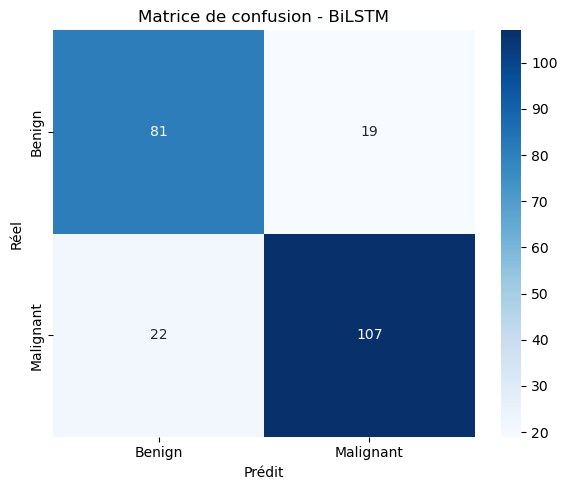

In [18]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Charger le modèle sauvegardé
model = load_model("BLSTM_classifier.keras")

# 2. Évaluer sur les données de test
loss, accuracy = model.evaluate(test_gen)
print(f"\nTest Accuracy : {accuracy * 100:.2f}% | Test Loss : {loss:.4f}")

# 3. Générer les prédictions
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

# 4. Rapport de classification
print("\nRapport de classification :")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

# 5. Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.title("Matrice de confusion - BiLSTM")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()


# RESNET50

In [18]:
from tensorflow import keras
base_model = keras.applications.ResNet50V2(
    weights="imagenet",  # Load weights pre-trained on ImageNet.
    input_shape=(224, 224, 3),
    include_top=False,
)  # Do not include the ImageNet classifier at the top.

# Freeze the base_model
base_model.trainable = False

# Create new model on top
inputs = keras.Input(shape=(224, 224, 3))


# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # Regularize with dropout
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [19]:
import warnings
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("Tumor_classifier_model1.keras", save_best_only=True, verbose=0)
]

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=callbacks,  
    verbose=1
)

C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1315s 10s/step - accuracy: 0.4886 - loss: 0.9017 - val_accuracy: 0.7287 - val_loss: 0.5994
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 635s 5s/step - accuracy: 0.7168 - loss: 0.5838 - val_accuracy: 0.8230 - val_loss: 0.4778
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 801s 6s/step - accuracy: 0.7985 - loss: 0.4756 - val_accuracy: 0.8483 - val_loss: 0.4221
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 802s 7s/step - accuracy: 0.8327 - loss: 0.4224 - val_accuracy: 0.8736 - val_loss: 0.3703
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 811s 7s/step - accuracy: 0.8500 - loss: 0.3885 - val_accuracy: 0.8782 - val_loss: 0.3609
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 739s 6s/step - accuracy: 0.8536 - loss: 0.3664 - val_accuracy: 0.9011 - val_loss: 0.3234
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 662s 5s/step - accuracy: 0.8702 - loss: 0.3437 - val_accuracy: 0.8759 - val_loss: 0.3470
Epoch 8/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 673s 5s/step - accuracy: 0.8818 - loss: 0.3229 

123/123 ━━━━━━━━━━━━━━━━━━━━ 1263s 10s/step - accuracy: 0.9126 - loss: 0.2224 - val_accuracy: 0.9149 - val_loss: 0.2357
Epoch 100/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1281s 10s/step - accuracy: 0.9109 - loss: 0.2309 - val_accuracy: 0.9103 - val_loss: 0.2297


15/15 ━━━━━━━━━━━━━━━━━━━━ 113s 6s/step


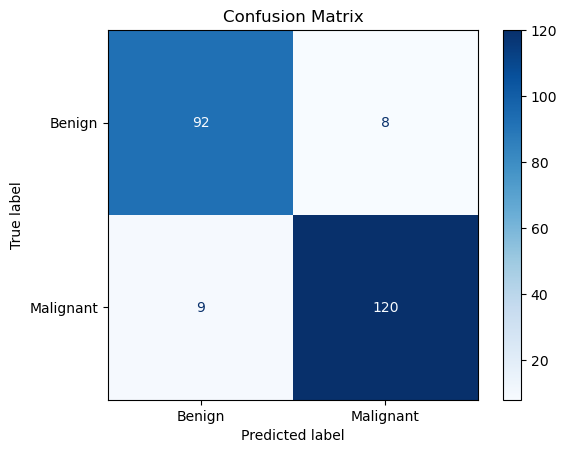

Classification Report:

              precision    recall  f1-score   support

      Benign       0.91      0.92      0.92       100
   Malignant       0.94      0.93      0.93       129

    accuracy                           0.93       229
   macro avg       0.92      0.93      0.92       229
weighted avg       0.93      0.93      0.93       229



In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("Tumor_classifier_model1.keras")

y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

def plot_history(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy per Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss per Epoch')
    plt.legend()
    plt.show()

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
from tensorflow.keras.models import load_model

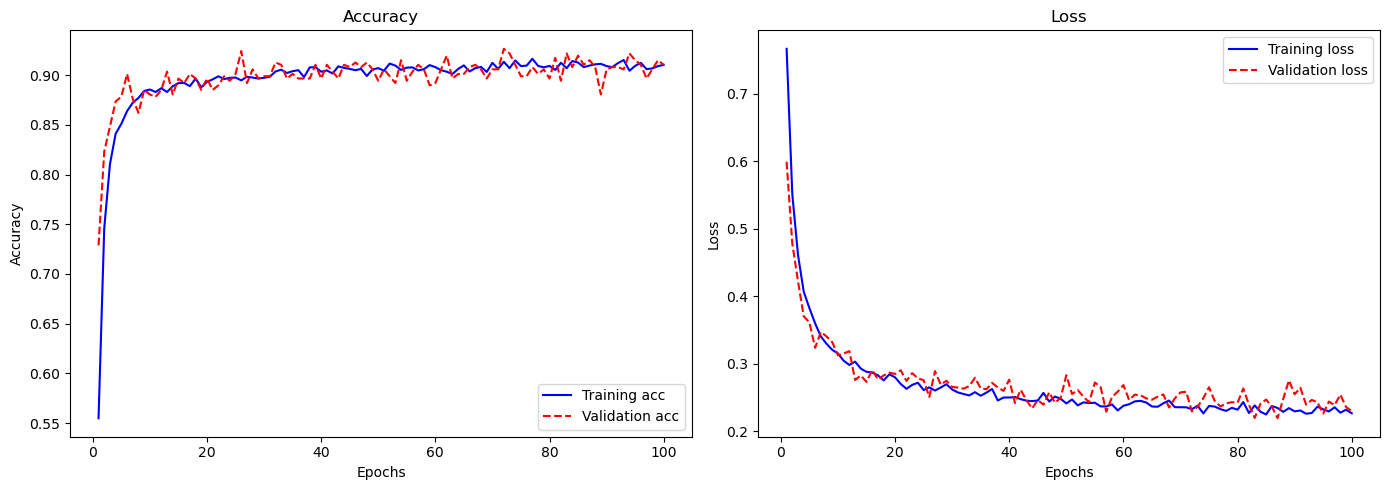

15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step


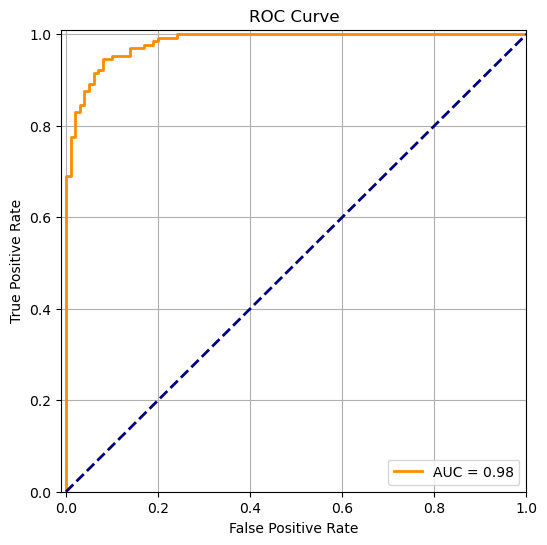

In [28]:

#ROC Curve
def plot_roc_curve(model, test_gen):
    from sklearn.metrics import roc_curve, auc

    y_true = test_gen.classes
    y_pred_proba = model.predict(test_gen)
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='AUC = %0.2f' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.01])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_learning_curves(history)
plot_roc_curve(model, test_gen)

15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step


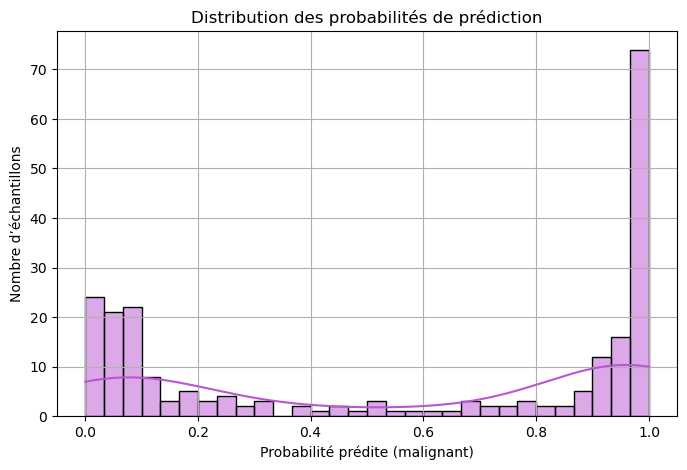

In [41]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_prediction_histogram(model, test_gen):
    y_pred = model.predict(test_gen).ravel()
    plt.figure(figsize=(8, 5))
    sns.histplot(y_pred, bins=30, kde=True, color='mediumorchid')
    plt.title("Distribution des probabilités de prédiction")
    plt.xlabel("Probabilité prédite (malignant)")
    plt.ylabel("Nombre d’échantillons")
    plt.grid(True)
    plt.show()

plot_prediction_histogram(model, test_gen)

C:\Users\user\AppData\Local\Temp\ipykernel_12564\2742590863.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette="mako")


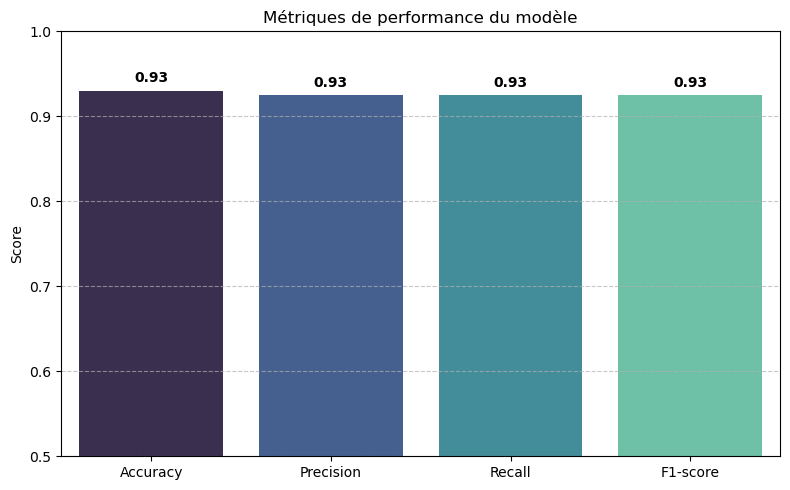

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# eetriques issues du classification report
metrics = {
    "Accuracy": 0.93,
    "Precision": (0.91 + 0.94) / 2,
    "Recall": (0.92 + 0.93) / 2,
    "F1-score": (0.92 + 0.93) / 2
}

# preparation des données
labels = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=values, palette="mako")

plt.ylim(0.5, 1.0)
plt.title("Métriques de performance du modèle")
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ajout des valeurs sur les barres
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step


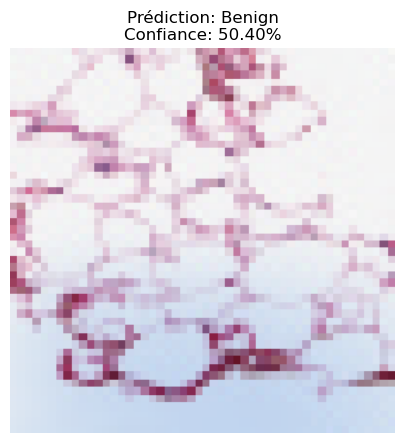

In [42]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_single_image(model, image_path):
    # Charger l’image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # prediction
    prediction = model.predict(img_array)[0][0]
    label = "Malignant" if prediction > 0.5 else "Benign"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # affichage
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prédiction: {label}\nConfiance: {confidence:.2%}")
    plt.show()

predict_single_image(model, r"D:\thesisIchrak\9083\0\9083_idx5_x251_y851_class0.png")

# VGG19

In [50]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
# VGG19 model
base_model = VGG19(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# train
callbacks = [tf.keras.callbacks.ModelCheckpoint("vgg19_model.keras", save_best_only=True)]

history = model.fit(train_gen, validation_data=val_gen,
                    epochs=20, callbacks=callbacks, verbose=1)

# evaluate test set
print("\n Evaluation on test set:")
model.evaluate(test_gen)


Epoch 1/20


C:\Users\user\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_597']. Received: the structure of inputs=*
  warnings.warn(


123/123 ━━━━━━━━━━━━━━━━━━━━ 2947s 24s/step - accuracy: 0.5070 - loss: 0.8568 - val_accuracy: 0.4690 - val_loss: 0.7176
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2541s 21s/step - accuracy: 0.5066 - loss: 0.7670 - val_accuracy: 0.5931 - val_loss: 0.6842
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1991s 16s/step - accuracy: 0.4931 - loss: 0.7362 - val_accuracy: 0.6207 - val_loss: 0.6753
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1792s 15s/step - accuracy: 0.5176 - loss: 0.7180 - val_accuracy: 0.6253 - val_loss: 0.6666
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1797s 15s/step - accuracy: 0.5332 - loss: 0.7038 - val_accuracy: 0.6115 - val_loss: 0.6638
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1059s 9s/step - accuracy: 0.5510 - loss: 0.6920 - val_accuracy: 0.6667 - val_loss: 0.6584
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1095s 9s/step - accuracy: 0.5508 - loss: 0.6914 - val_accuracy: 0.6828 - val_loss: 0.6502
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1076s 9s/step - accuracy: 0.5784 - loss: 0.6797 - val_ac

[0.6051656603813171, 0.6986899375915527]

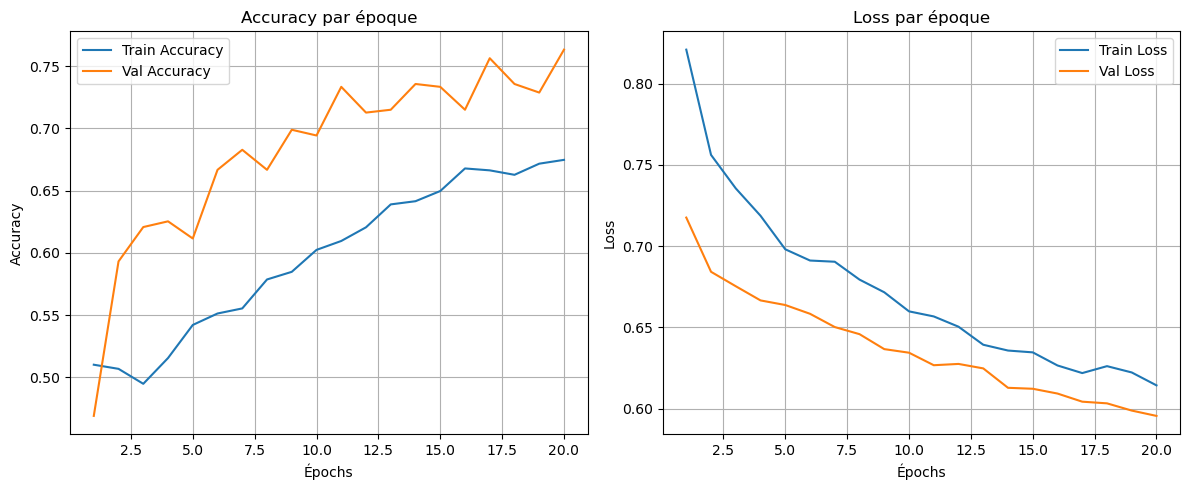

In [51]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Val Accuracy')
    plt.title('Accuracy par époque')
    plt.xlabel('Épochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Loss par époque')
    plt.xlabel('Épochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

15/15 ━━━━━━━━━━━━━━━━━━━━ 76s 5s/step


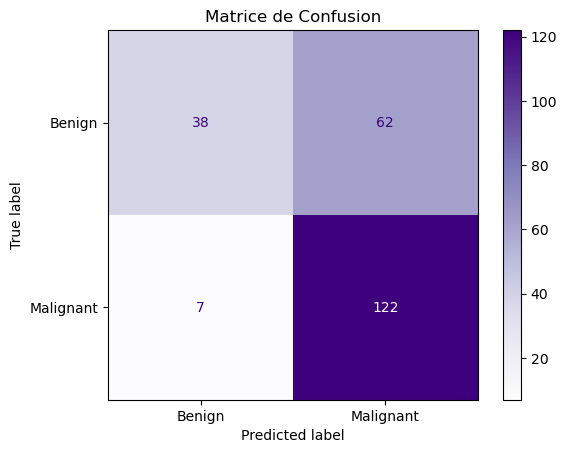


Classification Report :
              precision    recall  f1-score   support

      Benign       0.84      0.38      0.52       100
   Malignant       0.66      0.95      0.78       129

    accuracy                           0.70       229
   macro avg       0.75      0.66      0.65       229
weighted avg       0.74      0.70      0.67       229



In [52]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Prédictions sur l’ensemble de test
y_true = test_gen.classes
y_pred = model.predict(test_gen)
y_pred_labels = (y_pred >= 0.5).astype(int).flatten()

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Purples")
plt.title("Matrice de Confusion")
plt.show()

# Rapport de classification
print("\nClassification Report :")
print(classification_report(y_true, y_pred_labels, target_names=["Benign", "Malignant"]))


# EfficientNetB0

In [1]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False  
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint = ModelCheckpoint("EfficientNetB0_classifier.keras", save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


C:\Users\user\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor']. Received: the structure of inputs=*
  warnings.warn(


123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5151 - loss: 0.6992
Epoch 1: val_loss improved from inf to 0.69099, saving model to EfficientNetB0_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 527s 4s/step - accuracy: 0.5151 - loss: 0.6992 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5184 - loss: 0.6979
Epoch 2: val_loss improved from 0.69099 to 0.69077, saving model to EfficientNetB0_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accuracy: 0.5183 - loss: 0.6980 - val_accuracy: 0.5333 - val_loss: 0.6908
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5047 - loss: 0.6985
Epoch 3: val_loss did not improve from 0.69077
123/123 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.5047 - loss: 0.6985 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5237 - loss: 0.6962
Epoch 4: val_loss did not improve from 0.69077
123/123 ━━━━━━━━━━━━━━━━━━━

Epoch 26/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4988 - loss: 0.6995
Epoch 26: val_loss did not improve from 0.69059
123/123 ━━━━━━━━━━━━━━━━━━━━ 471s 4s/step - accuracy: 0.4988 - loss: 0.6995 - val_accuracy: 0.5333 - val_loss: 0.6908
Epoch 27/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4974 - loss: 0.7024
Epoch 27: val_loss improved from 0.69059 to 0.69059, saving model to EfficientNetB0_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 354s 3s/step - accuracy: 0.4974 - loss: 0.7024 - val_accuracy: 0.5333 - val_loss: 0.6906
Epoch 28/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5212 - loss: 0.6943
Epoch 28: val_loss did not improve from 0.69059
123/123 ━━━━━━━━━━━━━━━━━━━━ 495s 4s/step - accuracy: 0.5212 - loss: 0.6943 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 29/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5122 - loss: 0.7016
Epoch 29: val_loss did not improve from 0.69059
123/123 ━━━━━━━━━━━━━━━━━━━━ 451s 4s/step - accuracy: 0.5

In [15]:
from tensorflow.keras.models import load_model

model = load_model("EfficientNetB0_classifier.keras")

In [16]:
print("\nÉvaluation sur le jeu de test :")
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Test Accuracy : {test_accuracy:.4f} | Test Loss : {test_loss:.4f}")


Évaluation sur le jeu de test :
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 406ms/step - accuracy: 0.5249 - loss: 0.6915
Test Accuracy : 0.5633 | Test Loss : 0.6866


15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 845ms/step

Rapport de classification :
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       100
   Malignant       0.56      1.00      0.72       129

    accuracy                           0.56       229
   macro avg       0.28      0.50      0.36       229
weighted avg       0.32      0.56      0.41       229



C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


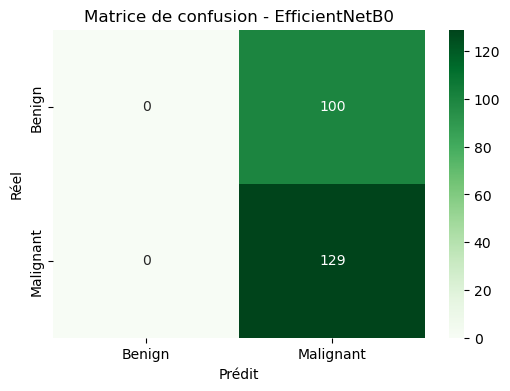

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

print("\nRapport de classification :")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.title("Matrice de confusion - EfficientNetB0")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

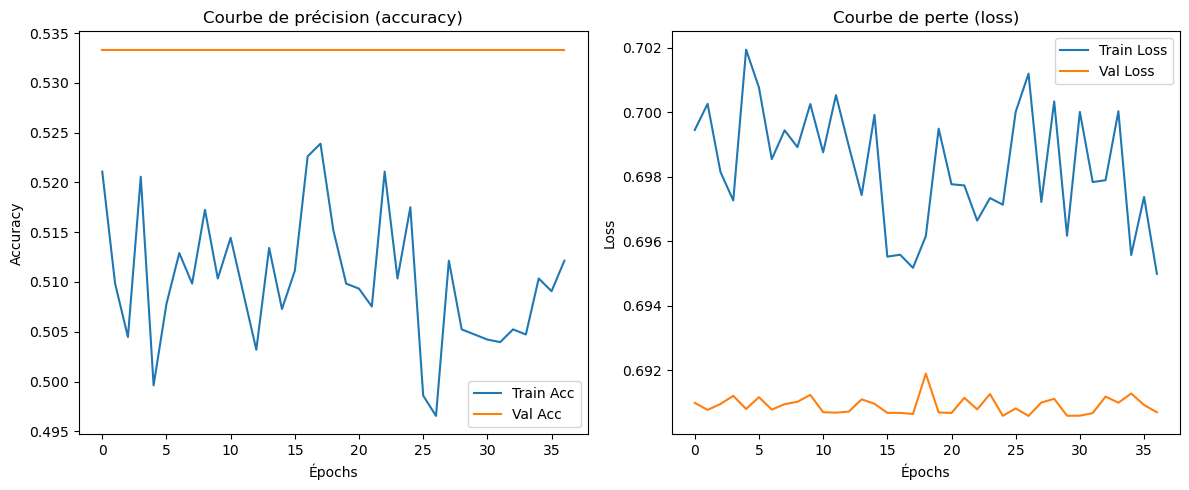

In [18]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Courbe de précision (accuracy)")
plt.xlabel("Épochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Courbe de perte (loss)")
plt.xlabel("Épochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Comparasion

In [21]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, log_loss
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

data_dir = r"D:\thesisIchrak\12908"  
df = pd.DataFrame()

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    if os.path.isdir(class_path):  
        for fname in os.listdir(class_path):
            df = pd.concat([df, pd.DataFrame({"filepaths": [os.path.join(class_path, fname)], "labels": [label]})])


# Conversion label en string 
df["labels"] = df["labels"].astype(str)

datagen = ImageDataGenerator(rescale=1./255)
test_gen = datagen.flow_from_dataframe(
    df,
    x_col="filepaths", y_col="labels",
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

models = {
    "CNN": r"C:\Users\user\Desktop\THESIS\data2\CNN_classifier.keras",
    "ResNet": r"C:\Users\user\Desktop\THESIS\data2\Tumor_classifier_best.keras",
    "VGG19": r"C:\Users\user\Desktop\THESIS\data2\vgg19_model.keras",
    "DenseNet121": r"C:\Users\user\Desktop\THESIS\data2\DenseNet121_classifier.keras",
    "EfficientNetB0": r"C:\Users\user\Desktop\THESIS\data2\EfficientNetB0_classifier.keras",
    "BLSTM": r"C:\Users\user\Desktop\THESIS\data2\BLSTM_classifier.keras"
}


# evaluation de chaque modele 
for name, path in models.items():
    print(f"\n--- Évaluation du modèle : {name} ---")
    model = load_model(path)
    y_true = test_gen.classes
    y_pred_prob = model.predict(test_gen).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))
    print(f"Log Loss: {log_loss(y_true, y_pred_prob):.4f}")


Found 400 validated image filenames belonging to 2 classes.

--- Évaluation du modèle : CNN ---


C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step
              precision    recall  f1-score   support

      Benign       0.94      0.93      0.93       198
   Malignant       0.93      0.94      0.94       202

    accuracy                           0.94       400
   macro avg       0.94      0.93      0.93       400
weighted avg       0.94      0.94      0.93       400

Log Loss: 0.1699

--- Évaluation du modèle : ResNet ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 532ms/step
              precision    recall  f1-score   support

      Benign       0.89      0.96      0.93       198
   Malignant       0.96      0.89      0.92       202

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.92       400
weighted avg       0.93      0.93      0.92       400

Log Loss: 0.1965

--- Évaluation du modèle : VGG19 ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step
              precision    recall  f1-score   support

      Benign       0.87      0.66      0.75       198
   M

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
              precision    recall  f1-score   support

      Benign       0.75      1.00      0.86       198
   Malignant       1.00      0.67      0.80       202

    accuracy                           0.83       400
   macro avg       0.88      0.84      0.83       400
weighted avg       0.88      0.83      0.83       400

Log Loss: 0.3744



--- Évaluation du modèle : CNN ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step

--- Évaluation du modèle : ResNet ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 797ms/step

--- Évaluation du modèle : VGG19 ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step

--- Évaluation du modèle : DenseNet121 ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step

--- Évaluation du modèle : EfficientNetB0 ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step

--- Évaluation du modèle : BLSTM ---


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step


C:\Users\user\AppData\Local\Temp\ipykernel_19620\1691468122.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="mako")


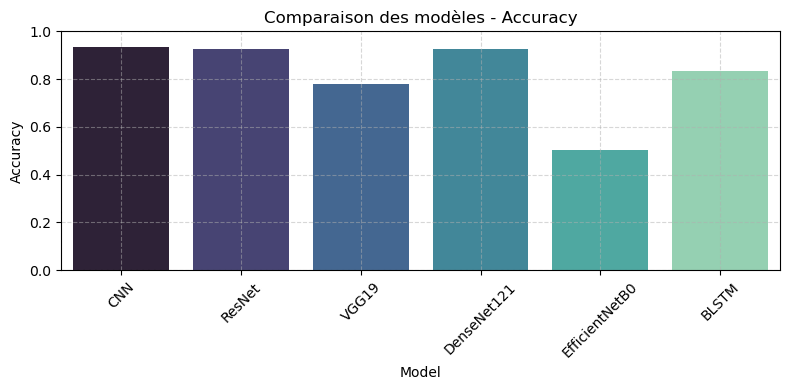

C:\Users\user\AppData\Local\Temp\ipykernel_19620\1691468122.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="mako")


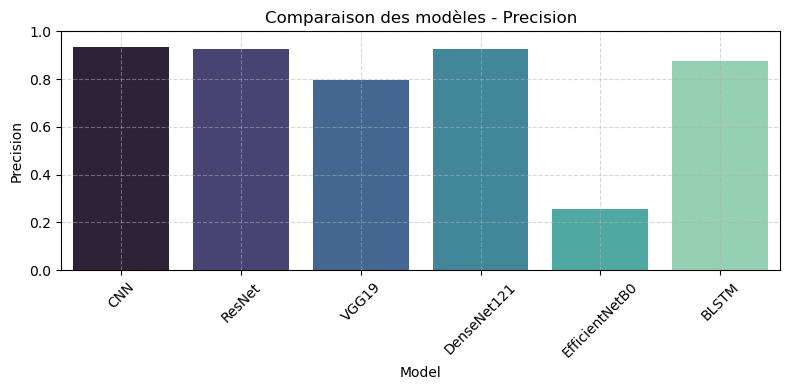

C:\Users\user\AppData\Local\Temp\ipykernel_19620\1691468122.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="mako")


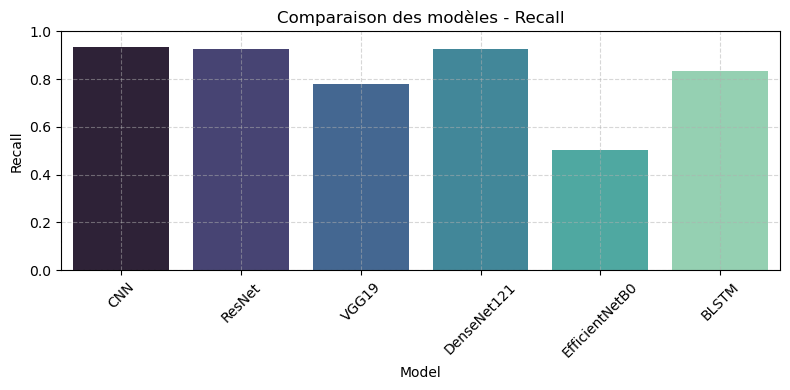

C:\Users\user\AppData\Local\Temp\ipykernel_19620\1691468122.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="mako")


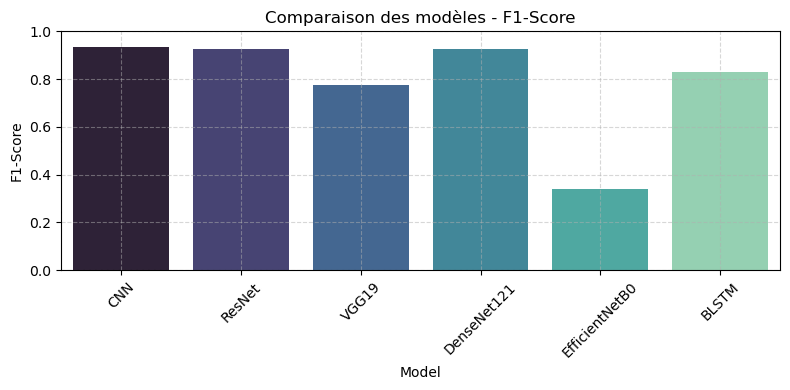

C:\Users\user\AppData\Local\Temp\ipykernel_19620\1691468122.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="mako")


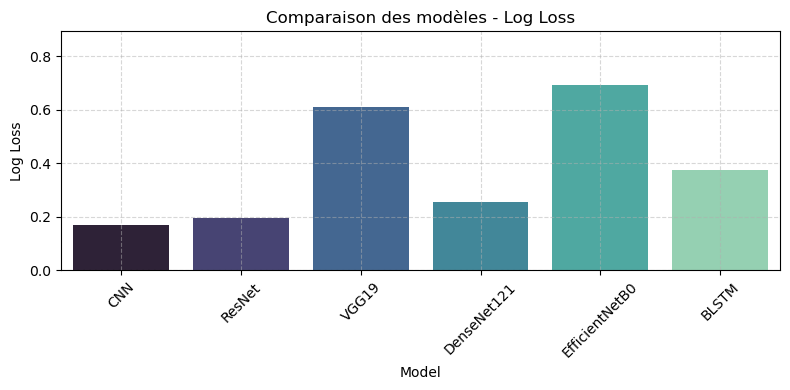

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, log_loss
from tensorflow.keras.models import load_model

# Récupération des résultats
metrics_dict = {}

for name, path in models.items():
    print(f"\n--- Évaluation du modèle : {name} ---")
    model = load_model(path)
    y_true = test_gen.classes
    y_pred_prob = model.predict(test_gen).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    report = classification_report(y_true, y_pred, target_names=["Benign", "Malignant"], output_dict=True)
    loss = log_loss(y_true, y_pred_prob)

    metrics_dict[name] = {
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"],
        "Log Loss": loss
    }

# Création DataFrame pour visualisation
results_df = pd.DataFrame.from_dict(metrics_dict, orient='index')
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)

# Affichage des graphes
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "Log Loss"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 4))
    sns.barplot(x="Model", y=metric, data=results_df, palette="mako")
    plt.title(f"Comparaison des modèles - {metric}")
    plt.ylim(0, 1 if metric != "Log Loss" else results_df[metric].max() + 0.2)
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Créer un DataFrame pour stocker les résultats
results_df = pd.DataFrame(columns=["Modèle", "Accuracy", "Précision", "Recall", "F1-score", "Log Loss"])

for name, path in models.items():
    print(f"\n--- Évaluation du modèle : {name} ---")
    model = load_model(path)
    
    # Prédictions
    y_true = test_gen.classes
    y_pred_prob = model.predict(test_gen).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Calcul des métriques
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    log = log_loss(y_true, y_pred_prob)

    # Affichage du rapport
    print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))
    print(f"Log Loss: {log:.4f}")

    # Ajout des résultats dans le tableau
    results_df = pd.concat([
        results_df,
        pd.DataFrame([{
            "Modèle": name,
            "Accuracy": f"{acc:.4f}",
            "Précision": f"{prec:.4f}",
            "Recall": f"{rec:.4f}",
            "F1-score": f"{f1:.4f}",
            "Log Loss": f"{log:.4f}"
        }])
    ], ignore_index=True)

# Afficher le tableau final
import matplotlib.pyplot as plt
import seaborn as sns

import ace_tools as tools; tools.display_dataframe_to_user(name="Comparaison des performances", dataframe=results_df)

plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x="Modèle", y="Accuracy")
plt.title("Comparaison des Accuracies par Modèle")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



--- Évaluation du modèle : CNN ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step
              precision    recall  f1-score   support

      Benign       0.94      0.93      0.93       198
   Malignant       0.93      0.94      0.94       202

    accuracy                           0.94       400
   macro avg       0.94      0.93      0.93       400
weighted avg       0.94      0.94      0.93       400

Log Loss: 0.1699

--- Évaluation du modèle : ResNet ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
              precision    recall  f1-score   support

      Benign       0.89      0.96      0.93       198
   Malignant       0.96      0.89      0.92       202

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.92       400
weighted avg       0.93      0.93      0.92       400

Log Loss: 0.1965

--- Évaluation du modèle : VGG19 ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step
              precision    recall  f1-score   support

      Benign       0.87 

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
              precision    recall  f1-score   support

      Benign       0.75      1.00      0.86       198
   Malignant       1.00      0.67      0.80       202

    accuracy                           0.83       400
   macro avg       0.88      0.84      0.83       400
weighted avg       0.88      0.83      0.83       400

Log Loss: 0.3744


ModuleNotFoundError: No module named 'ace_tools'